## ============================================================================

## E-COMMERCE FUNNEL ANALYTICS PROJECT
## NOTEBOOK: 03_FUNNEL_ANALYSIS

### PURPOSE:
### Measure how sessions progress from product views to carts and purchases.

## ============================================================================

## Analysis objectives

1. Load the cleaned event-level dataset.
2. Create one record per user session.
3. Identify whether each session reached each funnel stage.
4. Calculate session-level conversion and drop-off rates.
5. Visualize the progression from views to purchases.

This notebook measures sessions, not individual events. A session counts once at each stage, even if it contains multiple events of the same type.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams.update({
    "font.family": "Tahoma",
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

funnel_palette = {
    "View": "#8E97AC",
    "Cart": "#FFC400",
    "Purchase": "#6CB54D"
}
general_color = "#6670A3"
grid_color = "#E5E7EB"

def format_chart(ax):
    ax.grid(
        axis="both",
        color=grid_color,
        linewidth=0.8,
        alpha=0.8
    )

    sns.despine(
        ax=ax,
        top=True,
        right=True
    )

    return ax

## Load cleaned event data

The analysis uses the cleaned event-level dataset created during data preparation. The raw source file remains unchanged.

In [4]:
events = pd.read_csv("../data/processed/events_clean.csv", parse_dates=["event_time", "event_date"])

print("Cleaned file: ../data/processed/events_clean.csv")
print(f"Rows loaded: {len(events)}")
events.head()

Cleaned file: ../data/processed/events_clean.csv
Rows loaded: 884312


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_hour,category_level_1,category_level_2,category_level_3
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,Unknown,31.90,1515915625519388267,LJuJVLEjPT,2020-09-24,11,electronics,telephone,Unknown
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,2020-09-24,11,computers,components,cooler
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,Unknown,Unknown,9.81,1515915625513238515,4TMArHtXQy,2020-09-24,11,Unknown,Unknown,Unknown
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,2020-09-24,11,computers,peripherals,printer
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,Unknown,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ,2020-09-24,11,Unknown,Unknown,Unknown


## Build the session-level event flags

The raw dataset contains one row per event. To calculate funnel conversion, I need one row per session.

For each user and session, I will create boolean flags indicating whether the session included at least one view, cart, or purchase event. Grouping by both `user_id` and `user_session` prevents different users from being combined if a session identifier is reused.

In [6]:
session_event_flags = (
    events.assign(event_present=True)
    .pivot_table(
        index=["user_id", "user_session"],
        columns="event_type",
        values="event_present",
        aggfunc="max",
        fill_value=False,
        observed=True
    )
    .reindex(columns=["view", "cart", "purchase"], fill_value=False)
    .rename(columns={
        "view": "has_view",
        "cart": "has_cart",
        "purchase": "has_purchase"
    })
    .reset_index()
)

print(f"Session-level records: {len(session_event_flags)}")
session_event_flags.head()

Session-level records: 490633


event_type,user_id,user_session,has_view,has_cart,has_purchase
0,1515915625353226922,7qejzWzHlR,True,False,False
1,1515915625353230067,ikPKHkuRhA,True,False,False
2,1515915625353230683,5qXvZIBV2W,True,False,False
3,1515915625353230683,AXbHvG5BRP,True,False,False
4,1515915625353230683,YSbSzDlwcX,True,False,False


## Define the strict funnel

The strict funnel counts sessions that reached the stages in sequence:

- View: the session included at least one view.
- Cart: the session included both a view and a cart event.
- Purchase: the session included a view, a cart, and a purchase event.

This definition makes the conversion rates comparable between consecutive stages.

In [7]:
view_sessions = session_event_flags["has_view"]
view_and_cart_sessions = (
    session_event_flags["has_view"]
    & session_event_flags["has_cart"]
)
view_cart_and_purchase_sessions = (
    session_event_flags["has_view"]
    & session_event_flags["has_cart"]
    & session_event_flags["has_purchase"]
)

funnel_counts = pd.DataFrame({
    "funnel_stage": ["View", "Cart", "Purchase"],
    "session_count": [
        view_sessions.sum(),
        view_and_cart_sessions.sum(),
        view_cart_and_purchase_sessions.sum()
    ]
})

funnel_counts["conversion_rate"] = (
    funnel_counts["session_count"]
    .div(funnel_counts["session_count"].shift(1))
    .mul(100)
)

funnel_counts["overall_conversion_rate"] = (
    funnel_counts["session_count"]
    .div(funnel_counts.loc[0, "session_count"])
    .mul(100)
)

funnel_counts

,funnel_stage,session_count,conversion_rate,overall_conversion_rate
0,View,488586,NaN,100.00
1,Cart,41261,8.44,8.44
2,Purchase,20755,50.30,4.25


The first row has no previous stage, so its `conversion_rate` is intentionally empty.

`conversion_rate` measures the conversion from the previous stage, while `overall_conversion_rate` uses the view stage as the denominator.

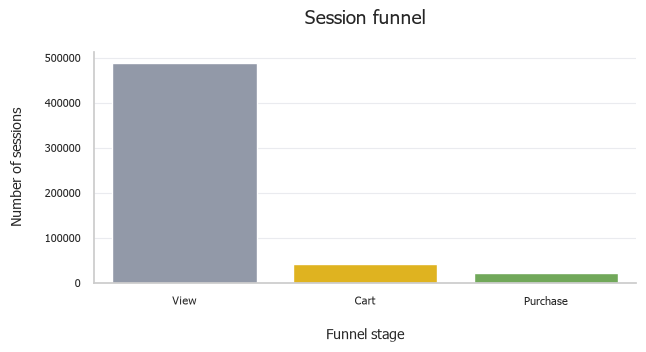

In [12]:
fig, ax = plt.subplots(figsize=(7, 3))

sns.barplot(
    data=funnel_counts,
    x="funnel_stage",
    y="session_count",
    hue="funnel_stage",
    hue_order=["View", "Cart", "Purchase"],
    palette=funnel_palette,
    legend=False,
    ax=ax
)

ax.set_title(
    "Session funnel", 
    pad=20
)

ax.set_xlabel(
    "Funnel stage", 
    labelpad=15
)
ax.set_ylabel(
    "Number of sessions", 
    labelpad=15
)

format_chart(ax)
ax.grid(axis="x", visible=False)

plt.show()

## Funnel data-quality check

Before interpreting the strict funnel, I will check whether any purchase sessions do not contain a cart event. These sessions are not included in the strict purchase stage because their event sequence is incomplete.

In [13]:
purchase_without_cart = (
    session_event_flags["has_purchase"]
    & ~session_event_flags["has_cart"]
)

purchase_without_view = (
    session_event_flags["has_purchase"]
    & ~session_event_flags["has_view"]
)

flow_quality = pd.DataFrame({
    "metric": [
        "Purchase sessions without cart",
        "Purchase sessions without view"
    ],
    "session_count": [
        purchase_without_cart.sum(),
        purchase_without_view.sum()
    ]
})

flow_quality

,metric,session_count
0,Purchase sessions without cart,3589
1,Purchase sessions without view,2034


## Validate event order

The previous analysis checked whether each session contained view, cart,
and purchase events. I will now validate whether these events occurred in
the expected chronological order.

In [15]:
session_event_times = (
    events.groupby(
        ["user_id", "user_session", "event_type"]
    )["event_time"]
    .min()
    .unstack("event_type")
    .reindex(columns=["view", "cart", "purchase"])
    .reset_index()
)

session_event_times["valid_funnel_order"] = (
    session_event_times["view"].notna()
    & session_event_times["cart"].notna()
    & session_event_times["purchase"].notna()
    & (session_event_times["view"] <= session_event_times["cart"])
    & (session_event_times["cart"] <= session_event_times["purchase"])
)

has_all_funnel_stages = (
    session_event_times[["view", "cart", "purchase"]]
    .notna()
    .all(axis=1)
)

order_summary = pd.DataFrame({
    "metric": [
        "Sessions with all funnel stages",
        "Sessions with valid funnel order",
        "Sessions with all stages but invalid order",
        "Sessions missing at least one stage"
    ],
    "session_count": [
        has_all_funnel_stages.sum(),
        session_event_times["valid_funnel_order"].sum(),
        (
            has_all_funnel_stages
            & ~session_event_times["valid_funnel_order"]
        ).sum(),
        (~has_all_funnel_stages).sum()
    ]
})

order_summary

,metric,session_count
0,Sessions with all funnel stages,20755
1,Sessions with valid funnel order,20519
2,Sessions with all stages but invalid order,236
3,Sessions missing at least one stage,469878


## Calculate the chronological funnel

I will calculate funnel stages based on the chronological order of the
observed events: view, cart, and purchase.

In [17]:
view_sessions_ordered = session_event_times["view"].notna()

view_then_cart_sessions = (
    view_sessions_ordered
    & session_event_times["cart"].notna()
    & (
        session_event_times["view"]
        <= session_event_times["cart"]
    )
)

view_then_cart_then_purchase_sessions = (
    view_then_cart_sessions
    & session_event_times["purchase"].notna()
    & (
        session_event_times["cart"]
        <= session_event_times["purchase"]
    )
)

ordered_funnel_counts = pd.DataFrame({
    "funnel_stage": ["View", "Cart", "Purchase"],
    "session_count": [
        view_sessions_ordered.sum(),
        view_then_cart_sessions.sum(),
        view_then_cart_then_purchase_sessions.sum()
    ]
})

ordered_funnel_counts["conversion_rate"] = (
    ordered_funnel_counts["session_count"]
    .div(ordered_funnel_counts["session_count"].shift(1))
    .mul(100)
)

ordered_funnel_counts["overall_conversion_rate"] = (
    ordered_funnel_counts["session_count"]
    .div(ordered_funnel_counts.loc[0, "session_count"])
    .mul(100)
)

ordered_funnel_counts

,funnel_stage,session_count,conversion_rate,overall_conversion_rate
0,View,488586,NaN,100.00
1,Cart,41257,8.44,8.44
2,Purchase,20519,49.73,4.20


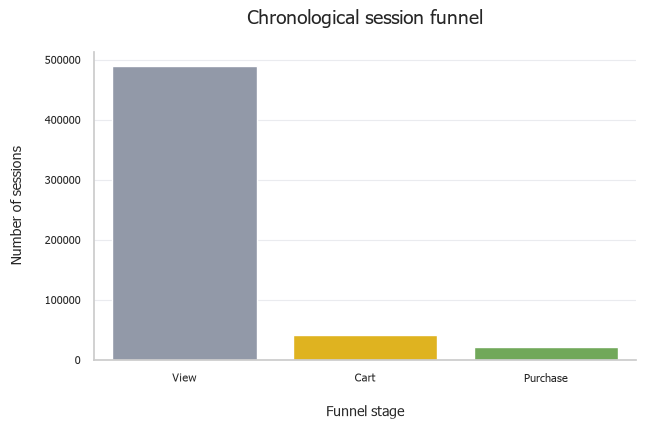

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=ordered_funnel_counts,
    x="funnel_stage",
    y="session_count",
    hue="funnel_stage",
    hue_order=["View", "Cart", "Purchase"],
    palette=funnel_palette,
    legend=False,
    ax=ax
)

ax.set_title(
    "Chronological session funnel",
    pad=20
)
ax.set_xlabel(
    "Funnel stage", 
    labelpad=15
)
ax.set_ylabel(
    "Number of sessions", 
    labelpad=15
)

format_chart(ax)
ax.grid(axis="x", visible=False)

plt.show()

## Compare funnel definitions

The comparison shows the difference between counting event presence and requiring the expected chronological order.

In [19]:
funnel_comparison = pd.DataFrame({
    "funnel_stage": ["View", "Cart", "Purchase"],
    "presence_based_sessions": funnel_counts["session_count"],
    "chronological_sessions": ordered_funnel_counts["session_count"]
})

funnel_comparison["difference"] = (
    funnel_comparison["presence_based_sessions"]
    - funnel_comparison["chronological_sessions"]
)

funnel_comparison

,funnel_stage,presence_based_sessions,chronological_sessions,difference
0,View,488586,488586,0
1,Cart,41261,41257,4
2,Purchase,20755,20519,236
